# Load the questions

In [63]:
import json
from time import sleep
from model_commons import AgentContext
import uuid
import re
from tqdm.notebook import tqdm
from langchain.messages import AIMessage, HumanMessage, AnyMessage

with open("benchmark.json") as f:
    qa = json.load(f)

# qa = {
#     "conversational": qa["conversational"],
#     "analytical": qa["analytical"]
# }

# Load the architectures to evaluate
| Ablation              | Short-Term Memory |        KB        | Vector DB Indexing | Bias Analysis Sub-Agent |
|-----------------------|:-----------------:|:----------------:|:------------------:|:-----------------------:|
| 0. **Vanilla**        |         Y         |       N/A        |        N/A         |            N            |
| 1. **Text RAG**       |         Y         |       CSV        |        Text        |            N            |
| 2. **MM-RAG**         |         Y         | CSV + Thumbnails |       Hybrid       |            N            |
| 3. **Agentic MM-RAG** |         Y         | CSV + Thumbnails |       Hybrid       |            Y            |

Depending on the question category, the questions may be grouped to lower the token usage.

In [63]:
def extract_token_usage(messages: list[AnyMessage]) -> int:
    return sum(
        (message.usage_metadata or {}).get("total_tokens", 0)
        for message in messages
        if getattr(message, "usage_metadata", None)
    )

In [64]:
from model_0 import agent as agent_0
from model_1 import agent as agent_1
from model_2 import agent as agent_2
from model_3 import agent as agent_3

user_id = 25
agents = [agent_0, agent_1, agent_2, agent_3]

for category in qa:
    pairs = [(pair["question"], pair["answer"]) for pair in qa[category]]
    thread_ids = [uuid.uuid4().hex for _ in agents] # each model is provided all previous Q&A pairs in the same category

    match category:
        case "factual":
            prompt = "Make sure you retrieved the last 5 watched videos, then answer very concisely as a bulleted list:\n"
            prompt += "\n".join(f"* {q}" for q, _ in pairs)
            
            print(f"\n[Q]\n{prompt}")
            print(f"[Expected]\n" + "\n".join(f"* {a}" for _, a in pairs))

            for i, agent in enumerate(agents):
                result = agent.invoke(
                    {"messages": [HumanMessage(content=prompt)]},
                    config={"configurable": {"thread_id": thread_ids[i]}},
                    context=AgentContext(user_id),
                ).get("messages", [])

                answer = result[-1].content
                usage = extract_token_usage(result)             # progress! since history includes previous
                print(f"\n[A{i}] (tokens: {usage})\n{answer}")  # TODO benchmark needs to be manually updated!

        case "conversational":
            prev_q = qa["analytical"][-1]["question"]
            prev_a = qa["analytical"][-1]["answer"]

            for i, (question, expected_answer) in tqdm(enumerate(pairs), desc="Question", total=len(pairs)):
                print(f"\n[Q]\n{question}")
                print(f"[Expected]\n{expected_answer}")
                
                for j, agent in enumerate(agents):
                    result = agent.invoke(
                        {"messages": [
                            HumanMessage(content=prev_q),
                            AIMessage(content=prev_a),
                            HumanMessage(content="Answer concisely: " + question)
                        ]},
                        config={"configurable": {"thread_id": thread_ids[j]}},
                        context=AgentContext(user_id),
                    ).get("messages", [])

                    answer = result[-1].content
                    usage = extract_token_usage(result)           # progress! since history includes previous
                    print(f"[A{j}] (tokens: {usage})\n{answer}")  # TODO benchmark needs to be manually updated!

        case _:
            for i, (question, expected_answer) in tqdm(enumerate(pairs), desc="Question", total=len(pairs)):
                print(f"\n[Q]\n{question}")
                print(f"[Expected]\n{expected_answer}")
                
                for j, agent in enumerate(agents):
                    result = agent.invoke(
                        {"messages": [HumanMessage(content="Answer concisely: " + question)]},
                        config={"configurable": {"thread_id": thread_ids[j]}},
                        context=AgentContext(user_id),
                    ).get("messages", [])
                    
                    answer = result[-1].content
                    usage = extract_token_usage(result)           # progress! since history includes previous
                    print(f"[A{j}] (tokens: {usage})\n{answer}")  # TODO benchmark needs to be manually updated!

    sleep(61)

Question:   0%|          | 0/4 [00:00<?, ?it/s]


[Q]
Using a tool, which title is the most similar to that?
[Expected]
The Vaccine Hoax They Don't Want You to Know.
[A0] (tokens: 4066)
'The Truth About Climate Hoaxes' is the most similar title.
[A1] (tokens: 1188)
The most similar title is "The Vaccine Hoax They Don't Want You to Know."
[A2] (tokens: 1341)
The most similar title is "The Vaccine Hoax They Don't Want You to Know."
[A3] (tokens: 1449)
The most similar title is "The Vaccine Hoax They Don't Want You to Know."

[Q]
What is its video ID?
[Expected]
CTj_xoCuhPU
[A0] (tokens: 8233)
The video ID for 'The Vaccine Hoax They Don't Want You to Know' is 100257.
[A1] (tokens: 1922)
The video ID is CTj_xoCuhPU.
[A2] (tokens: 2152)
The video ID is CTj_xoCuhPU.
[A3] (tokens: 2314)
The video ID is CTj_xoCuhPU.

[Q]
Using a tool, can you find the title of a similar watched video?
[Expected]
The Vaccine Truth Finally Revealed
[A0] (tokens: 12503)
'Climate Change Lies Exposed' is a similar watched video title.
[A1] (tokens: 3711)
The titl

KeyboardInterrupt: 

# Assign score to the answers

In [ ]:
import json
from time import sleep
from tqdm.notebook import tqdm
from typing import List
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from pydantic import SecretStr, BaseModel
from langchain.agents import create_agent
from langchain.messages import AIMessage, HumanMessage


class AnswerScore(BaseModel):
    score: float = Field(description="Score from 0.0 to 1.0")
    reason: str = Field(description="Short reason")

class AnswersEvaluation(BaseModel):
    evaluation: List[AnswerScore] = Field(description="List of scores for each answer")


with open("../../llm-api-key.txt") as f:
    llm = ChatOpenAI(
        model="gpt-4o-mini",
        api_key=SecretStr(f.readline().strip()),
        temperature=0,
    )

agent = create_agent(
    model=llm,
    response_format=AnswersEvaluation,
    system_prompt=(
        f"""
        You are a strict and consistent evaluator for answer correctness.
        Score each candidate model's answer against the golden answer. 

        # Input format
        Question: <question text>. Golden Answer: <golden answer text>. Answers to evaluate: [<answer1>, <answer2>, <answer3>, <answer4>].

        # Metrics
        - 1.0 for exact or fully correct answers, 
        - 0.7-0.9 for correct answers with extra text or minor formatting issues, 
        - 0.3-0.6 for partially correct answers, 
        - 0.0 for incorrect answers. 
        """
    ),
)

for category in qa:
    for question, golden_answer, answers in tqdm([(q["question"], q["answer"], q["answers"]) for q in qa[category]],desc=category):
        prompt = f"Question: {question}. Golden Answer: {golden_answer}. Answers to evaluate: {answers}"
        print(f"\n[Prompt]\n{prompt}")

        result = agent.invoke({"messages": [HumanMessage(content=prompt)]})
        
        print(f"\n[Raw Evaluation]")
        print(json.dumps([eval.model_dump() for eval in result["structured_response"].evaluation]))

        print(f"\n[Evaluation]")
        for i, eval in enumerate(result["structured_response"].evaluation):
            print(f"[{i+1}] {eval.score} - {eval.reason}")
        sleep(10)


factual:   0%|          | 0/4 [00:00<?, ?it/s]


[Prompt]
Question: What is the exact watch date and time for the video titled 'Why Small Biases Matter Over Time'?. Golden Answer: 2018-09-11 16:59:59. Answers to evaluate: ['2018-09-11 16:59:59', '2018-09-11 16:59:59 for “Why Small Biases Matter Over Time”', '2018-09-11 16:59:59 - “Why Small Biases Matter Over Time”', '2018-09-11 16:59:59 - “Why Small Biases Matter Over Time”']

[Raw Evaluation]
[{"score": 1.0, "reason": "Exact match with the golden answer."}, {"score": 0.7, "reason": "Correct date and time, but includes extra text."}, {"score": 0.7, "reason": "Correct date and time, but includes extra text."}, {"score": 0.7, "reason": "Correct date and time, but includes extra text."}]

[Evaluation]
[1] 1.0 - Exact match with the golden answer.
[2] 0.7 - Correct date and time, but includes extra text.
[3] 0.7 - Correct date and time, but includes extra text.
[4] 0.7 - Correct date and time, but includes extra text.

[Prompt]
Question: Which video ID corresponds to the video 'SkiVel'

cross_modal:   0%|          | 0/4 [00:00<?, ?it/s]


[Prompt]
Question: Based on the thumbnail at ../knowledge/thumbnails/z47r66-9XIg.jpg which video ID of the user's watch history is the most similar?. Golden Answer: 6CO6ShQd5i0. Answers to evaluate: ['Unable to determine the most similar video ID based on the thumbnail - the visual content of ../knowledge/thumbnails/z47r66-9XIg.jpg is not available in the watch-history data.', 'I’m unable to compare the thumbnail image to videos in the watch history because I don’t have a tool for visual similarity matching. Could you provide a textual description of the thumbnail or specify a video title to use for the comparison?', 'Video ID most similar to the thumbnail: z47r66-9XIg', 'The most similar video ID based on the thumbnail is z47r66-9XIg, titled "Spec Ops: Al Vahdeko - Sniper 3D Assassin: Shoot to Kill - Gameplay Walkthrough Part 9."']

[Raw Evaluation]
[{"score": 0.0, "reason": "The answer states an inability to determine similarity without visual content, which is incorrect as the gold

analytical:   0%|          | 0/4 [00:00<?, ?it/s]


[Prompt]
Question: What recurring topics does the user's watch history reveal based on the most recently watched 50 videos?. Golden Answer: Two recurring themes: (1) kids cartoons and nursery rhymes (Ben 10, StoryBots, Wiggles, Disney Kids), and (2) media/cognition/bias topics (The Subtle Effects of Repetition, How Exposure Shapes Beliefs, Why People Gravitate Toward Familiar Ideas, Why small biases matter).. Answers to evaluate: ['The user\'s recent watch history focuses on biases and their effects on thinking, as seen in titles like "Why Small Biases Matter Over Time" and "How Small Biases Accumulate." There is an emphasis on the influence of online discourse and content feeds, indicated by videos such as "The Gradual Shift in Online Discourse" and "Why Content Feeds Reinforce Views." The user also engages with children\'s content, including nursery rhymes and educational videos, suggesting a diverse interest in both serious and light-hearted topics.', 'The user\'s watch history rev

conversational:   0%|          | 0/4 [00:00<?, ?it/s]


[Prompt]
Question: Using a tool, which title is the most similar to that?. Golden Answer: The Vaccine Hoax They Don't Want You to Know.. Answers to evaluate: ["'The Truth About Climate Hoaxes' is the most similar title.", 'The most similar title is "The Vaccine Hoax They Don\'t Want You to Know."', 'The most similar title is "The Vaccine Hoax They Don\'t Want You to Know."', 'The most similar title is "The Vaccine Hoax They Don\'t Want You to Know."']

[Raw Evaluation]
[{"score": 0.0, "reason": "Incorrect title provided."}, {"score": 1.0, "reason": "Exact match to the golden answer."}, {"score": 1.0, "reason": "Exact match to the golden answer."}, {"score": 1.0, "reason": "Exact match to the golden answer."}]

[Evaluation]
[1] 0.0 - Incorrect title provided.
[2] 1.0 - Exact match to the golden answer.
[3] 1.0 - Exact match to the golden answer.
[4] 1.0 - Exact match to the golden answer.

[Prompt]
Question: What is its video ID?. Golden Answer: CTj_xoCuhPU. Answers to evaluate: ['The 

# Plotting

In [60]:
import os
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

output_dir = 'plots'
os.makedirs(output_dir, exist_ok=True)

plot_counter = 1
def show_and_save_plot():
    global plot_counter
    fig = plt.gcf()
    title = fig._suptitle.get_text() if fig._suptitle else plt.gca().get_title()
    if not title:
        title = f"plot_{plot_counter:03d}"
        plot_counter += 1
    filename = "".join(c if c.isalnum() or c in "._-" else "_" for c in title).replace(" ", "_") + ".png"
    plt.savefig(f"{output_dir}/{filename}", dpi=300, bbox_inches='tight', transparent=True)
    
plt.show = show_and_save_plot

## Scores distribution

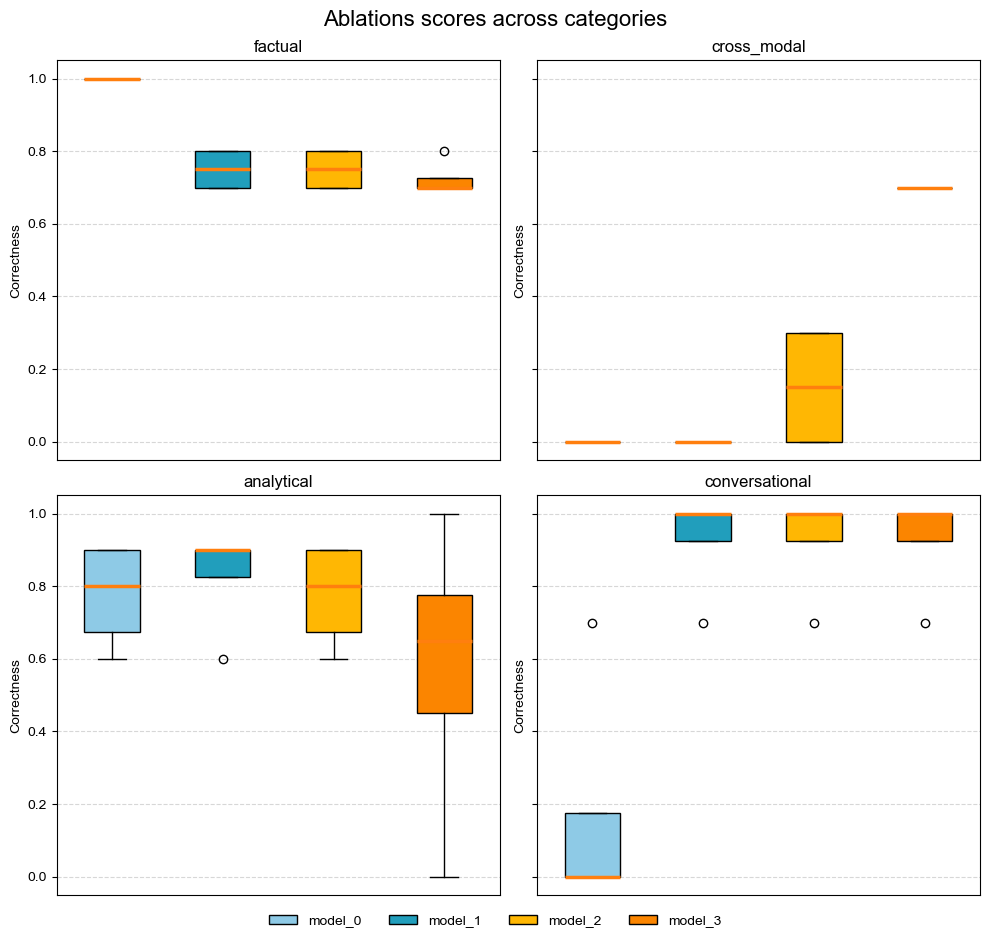

In [61]:
import json
import matplotlib.pyplot as plt

colors = ["#8ecae6", "#219ebc", "#ffb703", "#fb8500"]
models = ["model_0", "model_1", "model_2", "model_3"]

fig, axes = plt.subplots(2, 2, figsize=(10, 10), sharey=True)
axes = axes.ravel()

for ax, (category, items) in zip(axes, qa.items()):
    scores = [[] for _ in models]
    for item in items:
        for i, ev in enumerate(item["evaluations"]):
            scores[i].append(ev["score"])

    bp = ax.boxplot(
        scores,
        patch_artist=True,
        label=models,
        widths=0.5,
        medianprops={"linewidth": 2.5},
    )

    for box, c in zip(bp["boxes"], colors):
        box.set_facecolor(c)

    ax.set_title(category)
    ax.set_ylabel("Correctness")
    ax.set_xticks([])
    ax.yaxis.grid(linestyle="--", alpha=0.5)

fig.legend(
    bp["boxes"],
    models,
    loc="lower center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 0.05),
)

fig.suptitle("Ablations scores across categories", fontsize=16)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()


## Token usage distribution

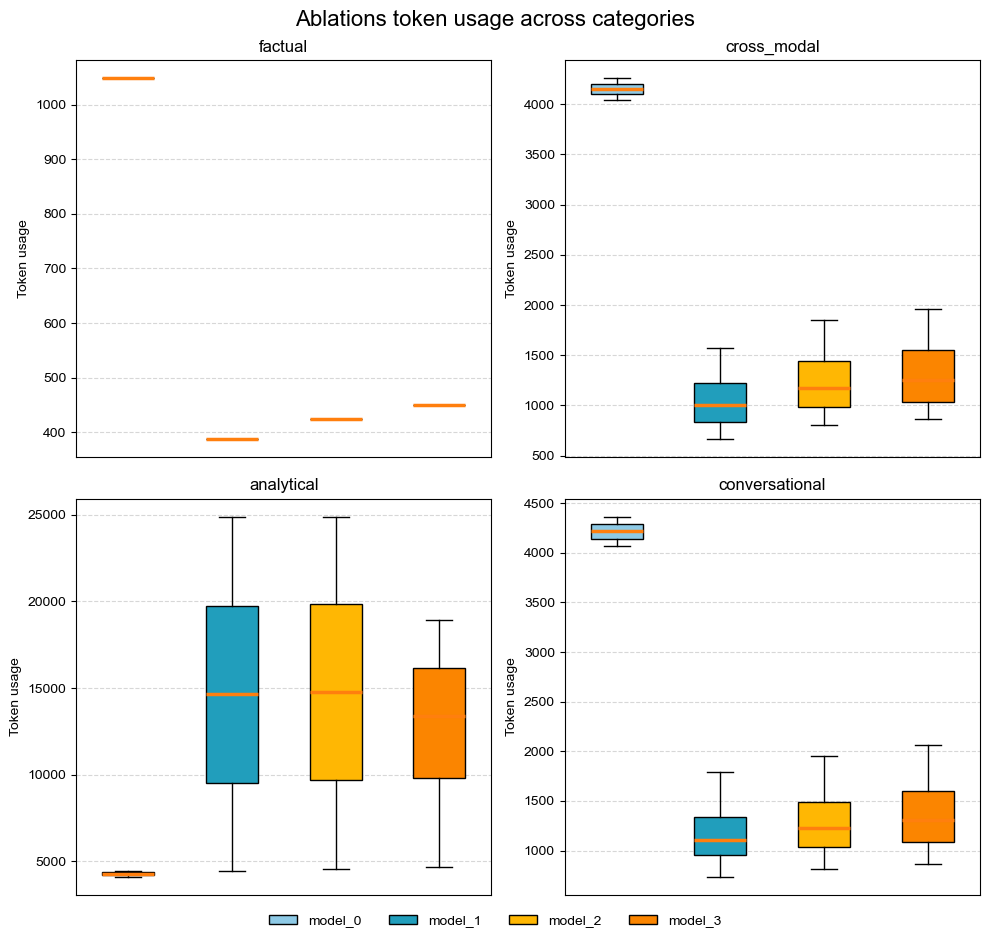

In [64]:
import matplotlib.pyplot as plt

colors = ["#8ecae6", "#219ebc", "#ffb703", "#fb8500"]
models = ["model_0", "model_1", "model_2", "model_3"]

fig, axes = plt.subplots(2, 2, figsize=(10, 10), sharey=False)
axes = axes.ravel()

for ax, (category, items) in zip(axes, qa.items()):
    usage = [[] for _ in models]
    previous = [0] * len(models)

    for item in items:
        for i, tokens in enumerate(item["usage"]):
            usage[i].append(tokens - previous[i])
            previous[i] = tokens

    bp = ax.boxplot(
        usage,
        patch_artist=True,
        widths=0.5,
        medianprops={"linewidth": 2.5},
    )

    for box, c in zip(bp["boxes"], colors):
        box.set_facecolor(c)

    ax.set_title(category)
    ax.set_ylabel("Token usage")
    ax.set_xticks([])
    ax.yaxis.grid(linestyle="--", alpha=0.5)

fig.legend(
    bp["boxes"],
    models,
    loc="lower center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 0.05),
)

fig.suptitle("Ablations token usage across categories", fontsize=16)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

## Cumulative token usage

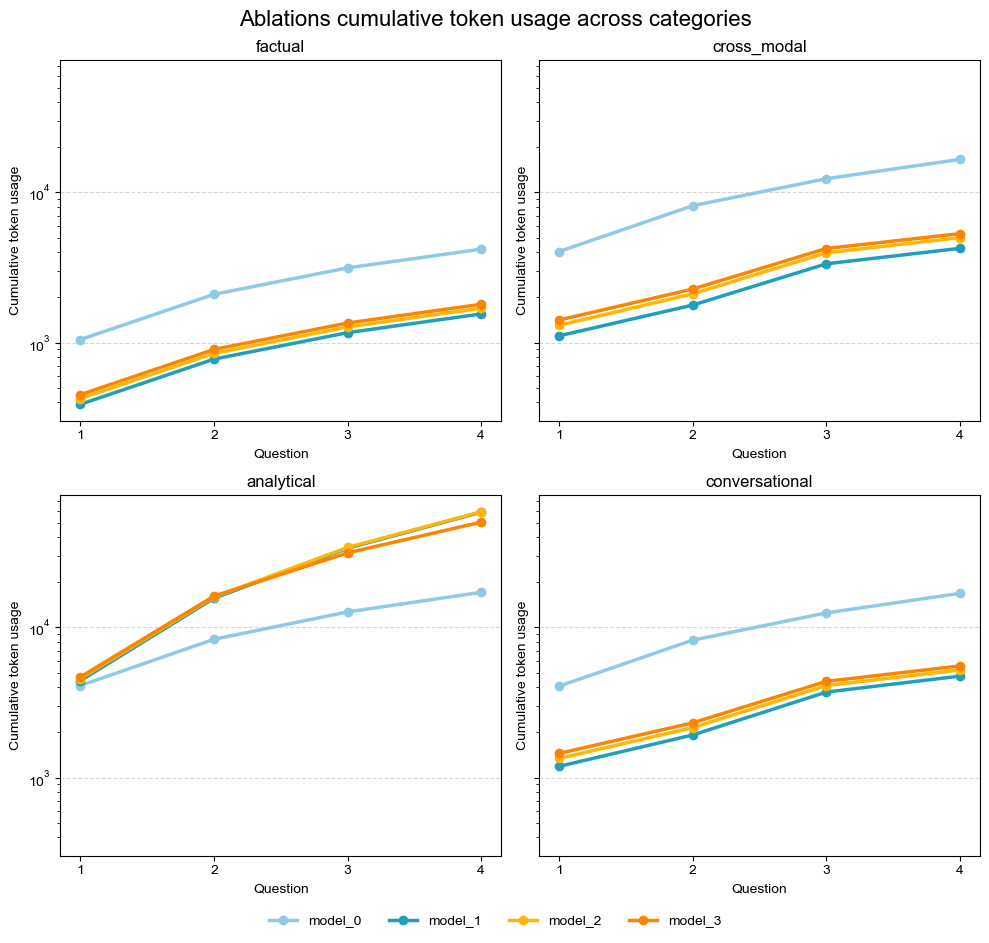

In [69]:
import matplotlib.pyplot as plt

colors = ["#8ecae6", "#219ebc", "#ffb703", "#fb8500"]
models = ["model_0", "model_1", "model_2", "model_3"]

fig, axes = plt.subplots(2, 2, figsize=(10, 10), sharey=True)
axes = axes.ravel()

for ax, (category, items) in zip(axes, qa.items()):
    for model_idx, (model, color) in enumerate(zip(models, colors)):
        y = [item["usage"][model_idx] for item in items]

        ax.plot(
            range(1, len(items) + 1),
            y,
            marker="o",
            linewidth=2.5,
            color=color,
            label=model,
        )

    ax.set_title(category)
    ax.set_xlabel("Question")
    ax.set_ylabel("Cumulative token usage")
    ax.set_yscale("log")
    ax.set_xticks(range(1, len(items) + 1))
    ax.yaxis.grid(linestyle="--", alpha=0.5)
    ax.set_axisbelow(True)

fig.legend(
    models,
    loc="lower center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 0.05),
)

fig.suptitle("Ablations cumulative token usage across categories", fontsize=16)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()